복잡한 문제를 해결하기 위해 문제를 분할 정복 하는 방법을 기본적으로 이용.
각 작업이나 도메인에 특화된 에이전트를 생성하고 작업을 올바른 에이전트에게 라우팅하는 방식.

In [75]:
!pip install langchain langchain_openai langsmith pandas langchain_experimental matplotlib langgraph langchain_core duckduckgo-search langchain-community

In [76]:
import os
from uuid import uuid4

In [77]:
unique_id = uuid4().hex[0:8]
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_PROJECT'] = f'Basic Multi_agent Collaboration - {unique_id}'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = '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'
os.environ['OPENAI_API_KEY'] = ''
os.environ['TAVILY_API_KEY'] = ''

In [78]:
unique_id

'8fa1bb3b'

Create Agent

In [79]:
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.graph import END, StateGraph, START

In [80]:
def create_agent(llm, tools, system_message: str):
    """Create an agent"""
    prompt = ChatPromptTemplate.from_messages([
        (
        'system',
        'You are a helpful AI assistant, collaborating with other assistants'
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        " You have access to the following tools: {tool_names}.\n{system_message}",
        ),
        MessagesPlaceholder(variable_name='messages'),
    ])
    prompt = prompt.partial(system_message=system_message)
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    return prompt | llm.bind_tools(tools)


Define tools

In [81]:
from typing import Annotated
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

In [82]:
tarvily_tool = TavilySearchResults(max_results = 5)

In [83]:
repl = PythonREPL()

@tool
def python_repl(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
     you should print it out with `print(...)`. This is visible to the user. """
    try:
        result = repl.run(code)
    except BaseException as e:
        return f'Failed to execute. Error: {repr(e)}'
    result_str = f'Successfully executed:\n```python\n{code}\n```\nStdout: {result}'
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

# create graph

define state

In [84]:
import operator
from typing import Annotated, Sequence, TypedDict
from langchain_openai import ChatOpenAI

In [85]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    sender: str

define agent nodes

In [86]:
import functools
from langchain_core.messages import AIMessage

In [87]:
def agent_node(state, agent, name):
    result = agent.invoke(state)
    return {
        'messages': [result],
        'sender': name,
    }
llm = ChatOpenAI(model='gpt-4o')

generate research agent

In [88]:
research_agent = create_agent(
    llm,
    [tarvily_tool],
    system_message='You should provide accurate data for use by searching the web. Always use the tavily_search tool to fetch the required data. Do not provide source code as the final answer.',
)
research_node = functools.partial(agent_node, agent=research_agent, name='Researcher')

Python 코드 실행기 사용 chart agent

In [ ]:
chart_agent = create_agent(
    llm,
    [python_repl],
    system_message='Generate and run Python code to create a line graph of the GDP data provided in the conversation. Use the python_repl tool to execute the code. Make sure to save the chart as an image file using plt.savefig(\'chart.png\') and include print statements to confirm. After successfully executing the code, respond with FINAL ANSWER.',
)
chart_node = functools.partial(agent_node, agent=chart_agent, name='chart_generator')

define tool node

In [90]:
from langgraph.prebuilt import ToolNode

tools = [tarvily_tool, python_repl]
tool_node = ToolNode(tools)

Define Edge Logic

In [91]:
from typing import Literal

In [92]:
def router(state) -> Literal['call_tool', '__end__', 'continue']:
    messages = state['messages']
    last_message = messages[-1]
    tool_calls = getattr(last_message, 'tool_calls', None)
    if tool_calls:
        return 'call_tool'
    if 'FINAL ANSWER' in getattr(last_message, 'content', ''):
        return '__end__'
    return 'continue'

define the graph

In [93]:
workflow = StateGraph(AgentState)

workflow.add_node('Researcher', research_node)
workflow.add_node('chart_generator', chart_node)
workflow.add_node('call_tool', tool_node)

workflow.add_conditional_edges(
    'Researcher',
    router,
    {'continue': 'chart_generator', 'call_tool': 'call_tool', '__end__': END},
)
workflow.add_conditional_edges(
    'chart_generator',
    router,
    {'continue': 'Researcher', 'call_tool': 'call_tool', '__end__': END},
)
workflow.add_conditional_edges(
    'call_tool',
    lambda x: x['sender'],
    {'Researcher': 'Researcher', 'chart_generator': 'chart_generator',},
)
workflow.add_edge(START, 'Researcher')
graph = workflow.compile()

In [94]:
from IPython.display import Image, display

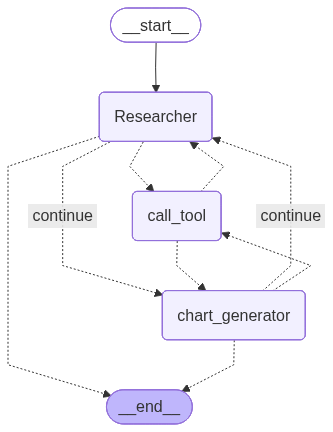

In [95]:
try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

invoke

{'Researcher': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 240, 'total_tokens': 271, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_246dab3317', 'id': 'chatcmpl-DZvEMZUIw8Sd6h9AMn719kGsjMyIv', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dd881-4eb4-7b23-aa52-d970bd4678c1-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'USA GDP for 2021, 2022, 2023'}, 'id': 'call_En3BCpUAuSHXClsaafzJtgZN', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 240, 'output_tokens': 31, 'total_tokens': 271, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'ou

Python REPL can execute arbitrary code. Use with caution.


{'chart_generator': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 163, 'prompt_tokens': 3665, 'total_tokens': 3828, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_ce01354fe1', 'id': 'chatcmpl-DZvEVFNUzieyG9COcTHVu6JOy12R8', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dd881-70d8-7180-9d0e-c80d01243362-0', tool_calls=[{'name': 'python_repl', 'args': {'code': 'import matplotlib.pyplot as plt\n\n# Data\nyears = [2021, 2022, 2023]\ngdp_values = [23.681, 26.007, 27.721]  # Trillions of dollars\n\n# Plot\nplt.figure(figsize=(8, 5))\nplt.plot(years, gdp_values, marker=\'o\', linestyle=\'-\', color=\'b\')\n\n# Adding label

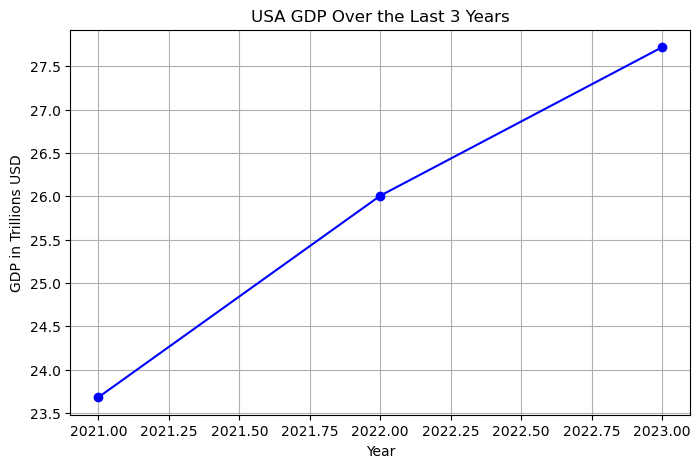

{'call_tool': {'messages': [ToolMessage(content='Successfully executed:\n```python\nimport matplotlib.pyplot as plt\n\n# Data\nyears = [2021, 2022, 2023]\ngdp_values = [23.681, 26.007, 27.721]  # Trillions of dollars\n\n# Plot\nplt.figure(figsize=(8, 5))\nplt.plot(years, gdp_values, marker=\'o\', linestyle=\'-\', color=\'b\')\n\n# Adding labels and title\nplt.title("USA GDP Over the Last 3 Years")\nplt.xlabel("Year")\nplt.ylabel("GDP in Trillions USD")\n\n# Adding grid for better readability\nplt.grid(True)\n\n# Display\nplt.show()\n```\nStdout: \n\nIf you have completed all tasks, respond with FINAL ANSWER.', name='python_repl', tool_call_id='call_ImW7RB7Qj8foAy0EUqAGz2uM')]}}
----
{'chart_generator': {'messages': [AIMessage(content="FINAL ANSWER: The line graph of the USA's GDP over the past three years (2021 to 2023) has been successfully created and displayed using Matplotlib. The GDP values were:\n- 2021: $23.681 trillion\n- 2022: $26.007 trillion\n- 2023: $27.721 trillion", addit

In [97]:
events = graph.stream(
    {
        "messages": [
            HumanMessage(
                content="Fetch the USA's GDP over the past 3 years,"
                " then draw a line graph of it."
                " Once you code it up, finish."
            )
        ],
    },
    {"recursion_limit": 30},
)
for s in events:
    print(s)
    print("----")